# 데이터마이닝및실습 팀 과제 최종보고서

## 0. 팀원
- 김송하(컴퓨터전자시스템공학부, 202000715)
- 정민규(컴퓨터전자시스템공학부, 202003121)

## 1. 프로젝트 개요
### 목표
본 프로젝트의 목적은 Car Sales Dataset을 활용하여 차량의 주요 특성(엔진 크기, 연식, 주행거리 등)과 차량 가격 간의 관계를 분석하고, 여러 머신러닝 알고리즘(SVM, Decision Tree, Random Forest)을 이용하여 차량 가격 예측 모델을 구축한 후 각 모델의 성능을 비교 분석하는 것이다. 이를 위해 데이터 전처리, 이상치 제거, 변수 간 상관관계 분석, feature selection 과정을 수행하고, 이후 여러 머신러닝 모델을 적용하여 예측 성능을 평가한다.

### 실험 환경
- R 버전: 4.3.2 (2023-10-31)
- R 패키지 버전 : pROC_1.18.5, reshape2_1.4.4, MASS_7.3-60, MLmetrics_1.1.1, yardstick_1.2.0, caret_6.0-94, lattice_0.21-9, rpart_4.1.23, randomForest_4.7-1.1, e1071_1.7-14, corrplot_0.92, ggplot2_3.4.4, readr_2.1.4, dplyr_1.1.4

## 2. 프로젝트 과정
### 사용한 데이터 셋
- Car Sales Dataset: Model, Features, and Pricing: https://www.kaggle.com/datasets/msnbehdani/mock-dataset-of-second-hand-car-sales
    - Size: total data size: 50000
    - columns : 7 ('Manufacturer', 'Model', 'Engine size', 'Fuel type', 'Year of manufacture', 'Mileage''Price')

### 사용한 모델
#### Support Vector Machines (SVM)
![svm.png](http://localhost:8888/files/Projects/2023-2/svm.png)
- 주어진 데이터가 어느 카테고리에 속할지 판단하는 이진 선형 분류 모델. 서포트 벡터들의거리인 마진의 최대치를 찾는 것이 svm의 목표이다.
- svm모델의 장점으로는 분류문제와 예측문제 동시에 쓸 수 있고, 신경망 기법에 비해 과적합 정도가 덜하고 예측의 정확도가 높다. 그리고 사용하기 쉽다.
- 이 모델의 단점으로는 kernel과 모델 파라미터를 조절하기 위한 테스트를 여러 번 해봐야 최적화된 모형을 만들 수 있고, 모형 구축 시간이 오래 걸린다. 또한 결과에 대한 설명력이 떨어진다는 단점이 있다.

#### Decision Trees
![dt.png](http://localhost:8888/files/Projects/2023-2/dt.jpg)
- decision tree란 입력값에 대한 예측값을 노드로 가지는 tree로 나타내어주는 모형.설명변수 간의 관계나 척도에 따라 목표변수를 예측하거나 분류하는 문제에 활용되는 트리 구조의 모델이다. 설명변수의 관측값을 모델에 입력해 목표변수를 분류하거나 예측하는 지도학습 기반의 방법론이다.
- 의사결정 트리 모델을 사용하는 주된 이유는 목표변수를 예측하거나 분류 문제를 해결함에 있어서 어떤 설명변수가 가장 중요한 영향인자인지 확인할 수 있고, 나아가 설명변수별로 어떤 척도에 따라 예측 또는 분류했는지 상세한 기준을 알 수 있다는 장점이 있다.

#### Random Forest
![rf.png](http://localhost:8888/files/Projects/2023-2/rf.png)
- 기존 decision tree의 이점을 살리고 Bagging변수를 랜덤으로 선택하는 과정을 추가함으로써 개별 노드들의 상관성을 줄여 예측력을 향상한 앙상블 모형. 램덤 포레스트는 램덤성에 의해 트리들이 서로 조금씩 다른 특성을 갖는 특성이 있다. 
- 이 특성은 각 트리들의 예측들이 비상관화 되게하며, 겨로가적으로 일반화 성능을 향상시키는 효과가 있다.

#### Logistic Regression
![lr.png](http://localhost:8888/files/Projects/2023-2/lr.png)
- 수학을 사용하여 두 데이터 요인 간의 관계를 찾는 데이터 분석 기법으로 두 데이터 간의 관계를 사용하여 다른 요인을 기반으로 이러한 요인 중 하나의 값을 예측한다. 예측은 일반적으로 유한한 수의 결과를 가진다. 
- 로지스틱 회귀는 간편성, 속도, 유연성, 가시성 부분에서 장점을 가진다.

In [1]:
# 필요한 패키지 설치 및 불러오기
# install.packages("dplyr")
# install.packages("readr")
# install.packages("ggplot2")
# install.packages("corrplot")
# install.packages("e1071")
# install.packages("randomForest")
# install.packages("rpart")
# install.packages("caret")
# install.packages("yardstick")
# install.packages("MLmetrics")
# install.packages("MASS")

library(dplyr)
library(readr)
library(ggplot2)
library(corrplot)
library(e1071)
library(randomForest)
library(rpart)
library(caret)
library(ggplot2)
library(corrplot)
library(caret)
library(e1071)
library(yardstick)
library(MLmetrics)
library(MASS)


다음의 패키지를 부착합니다: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


corrplot 0.92 loaded

randomForest 4.7-1.1

Type rfNews() to see new features/changes/bug fixes.


다음의 패키지를 부착합니다: ‘randomForest’


The following object is masked from ‘package:ggplot2’:

    margin


The following object is masked from ‘package:dplyr’:

    combine


필요한 패키지를 로딩중입니다: lattice


다음의 패키지를 부착합니다: ‘yardstick’


The following objects are masked from ‘package:caret’:

    precision, recall, sensitivity, specificity


The following object is masked from ‘package:readr’:

    spec



다음의 패키지를 부착합니다: ‘MLmetrics’


The following objects are masked from ‘package:caret’:

    MAE, RMSE


The following object is masked from ‘package:base’:

    Recall



다음의 패키지를 부착합니다: ‘MASS’


The following object is masked from ‘package:dplyr’:

    select




In [2]:
# 자동차 데이터 읽기
car_sales <- read_csv('/Users/kimsongha/Projects/2023-2/car_sales_data.csv', col_types = cols())

# 결측치 확인

In [3]:
# 전체 데이터 프레임에서 누락된 값이 있는지 확인
sum(is.na(car_sales))

[1] 0

# 데이터 확인

In [4]:
head(car_sales)

Manufacturer,Model,Engine size,Fuel type,Year of manufacture,Mileage,Price
<chr>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
Ford,Fiesta,1.0,Petrol,2002,127300,3074
Porsche,718 Cayman,4.0,Petrol,2016,57850,49704
Ford,Mondeo,1.6,Diesel,2014,39190,24072
Toyota,RAV4,1.8,Hybrid,1988,210814,1705
VW,Polo,1.0,Petrol,2006,127869,4101
Ford,Focus,1.4,Petrol,2018,33603,29204


In [5]:
names(car_sales)

[1] "Manufacturer"        "Model"               "Engine size"        
[4] "Fuel type"           "Year of manufacture" "Mileage"            
[7] "Price"

In [6]:
names(car_sales) <- gsub(" ", "_", names(car_sales))

In [7]:
names(car_sales)

[1] "Manufacturer"        "Model"               "Engine_size"        
[4] "Fuel_type"           "Year_of_manufacture" "Mileage"            
[7] "Price"

In [8]:
# 기본 정보 출력 함수 정의
info <- function(df) {
  # 데이터 프레임의 기본 구조
  print(str(df))

  # 각 열의 요약 정보
  sapply(df, function(x) {
    c(type = class(x), n_missing = sum(is.na(x)))
  })
}

# 함수 실행
info(car_sales)

spc_tbl_ [50,000 × 7] (S3: spec_tbl_df/tbl_df/tbl/data.frame)
 $ Manufacturer       : chr [1:50000] "Ford" "Porsche" "Ford" "Toyota" ...
 $ Model              : chr [1:50000] "Fiesta" "718 Cayman" "Mondeo" "RAV4" ...
 $ Engine_size        : num [1:50000] 1 4 1.6 1.8 1 1.4 1.8 1.4 1.2 2 ...
 $ Fuel_type          : chr [1:50000] "Petrol" "Petrol" "Diesel" "Hybrid" ...
 $ Year_of_manufacture: num [1:50000] 2002 2016 2014 1988 2006 ...
 $ Mileage            : num [1:50000] 127300 57850 39190 210814 127869 ...
 $ Price              : num [1:50000] 3074 49704 24072 1705 4101 ...
 - attr(*, "spec")=
  .. cols(
  ..   Manufacturer = col_character(),
  ..   Model = col_character(),
  ..   `Engine size` = col_double(),
  ..   `Fuel type` = col_character(),
  ..   `Year of manufacture` = col_double(),
  ..   Mileage = col_double(),
  ..   Price = col_double()
  .. )
 - attr(*, "problems")=<externalptr> 
NULL


,Manufacturer,Model,Engine_size,Fuel_type,Year_of_manufacture,Mileage,Price
type,character,character,numeric,character,numeric,numeric,numeric
n_missing,0,0,0,0,0,0,0


# 이상치 확인 및 제거

In [9]:
# 가격을 3개 등급으로 나누기
q <- quantile(car_sales$Price, probs = c(0, 1/3, 2/3, 1), na.rm = TRUE)

car_sales$Price_category <- cut(
  car_sales$Price,
  breaks = q,
  include.lowest = TRUE,
  labels = c("Low", "Medium", "High")
)

In [10]:
# 수치형 열만 추출
numeric_cols <- sapply(car_sales, is.numeric)

# 수치형 열에 대해서만 Z-score 계산
z_scores <- as.data.frame(scale(car_sales[, numeric_cols]))

# 모든 수치형 변수에서 |z| < 3 인 행만 선택
filtered_entries <- apply(z_scores, 1, function(x) all(abs(x) < 3))

# 원본 데이터프레임에서 해당 행만 유지
cars_new <- car_sales[filtered_entries, ]

In [11]:
cars_new_rows <- nrow(cars_new)

# 원본 데이터프레임에 있는 행의 수 확인
car_sales_rows <- nrow(car_sales)

# 데이터셋에서 줄어든 행의 수 계산
car_reduction <- car_sales_rows - cars_new_rows

# 전체 행에서 줄어든 행의 백분율 계산
car_reduction_percent <- (car_reduction / car_sales_rows) * 100

# 결과 출력
cat(car_reduction, "outliers have been removed from the car_sales_rows dataset, which represents", round(car_reduction_percent, 2), "% of the original dataset.")

2848 outliers have been removed from the car_sales_rows dataset, which represents 5.7 % of the original dataset.

In [12]:
# 원본 데이터 세트: 각 가격 등급에 대한 차량 개수 계산
price_category_counts <- table(car_sales$Price_category)
price_category_counts_sorted <- sort(price_category_counts)

# 원본 데이터 세트에 대해 정렬된 가격 등급 개수 인쇄하기
cat("Original Dataset Price Category Counts:\n")
print(price_category_counts_sorted)
cat("\nNumber of rows in original dataset:", nrow(car_sales), "\n")
cat("Number of columns in original dataset:", ncol(car_sales), "\n\n")

Original Dataset Price Category Counts:

  High Medium    Low 
 16665  16666  16669 

Number of rows in original dataset: 50000 
Number of columns in original dataset: 8 



In [13]:
# 필터링된 데이터 세트: 필터링된 데이터 세트에 대해 동일한 작업 수행 (cars_new)

price_category_counts_filtered <- table(cars_new$Price_category)
price_category_counts_filtered_sorted <- sort(price_category_counts_filtered)

# 필터링된 데이터 세트에 대해 정렬된 가격 등급 개수 인쇄하기
cat("Filtered Dataset Price Category Counts:\n")
print(price_category_counts_filtered_sorted)
cat("\nNumber of rows in filtered dataset:", nrow(cars_new), "\n")
cat("Number of columns in filtered dataset:", ncol(cars_new), "\n")

Filtered Dataset Price Category Counts:

  High Medium    Low 
 14842  16115  16195 

Number of rows in filtered dataset: 47152 
Number of columns in filtered dataset: 8 


# 데이터 시각화 및 분석

In [14]:
# 상관 관계 계산 (수치형 변수만 사용)
numeric_cols <- sapply(cars_new, is.numeric)
correlation_matrix <- cor(cars_new[, numeric_cols])

print(correlation_matrix)

                    Engine_size Year_of_manufacture     Mileage      Price
Engine_size          1.00000000         -0.02777726  0.02541743  0.2469487
Year_of_manufacture -0.02777726          1.00000000 -0.80514274  0.8139719
Mileage              0.02541743         -0.80514274  1.00000000 -0.7311214
Price                0.24694875          0.81397192 -0.73112140  1.0000000


# Heat Map

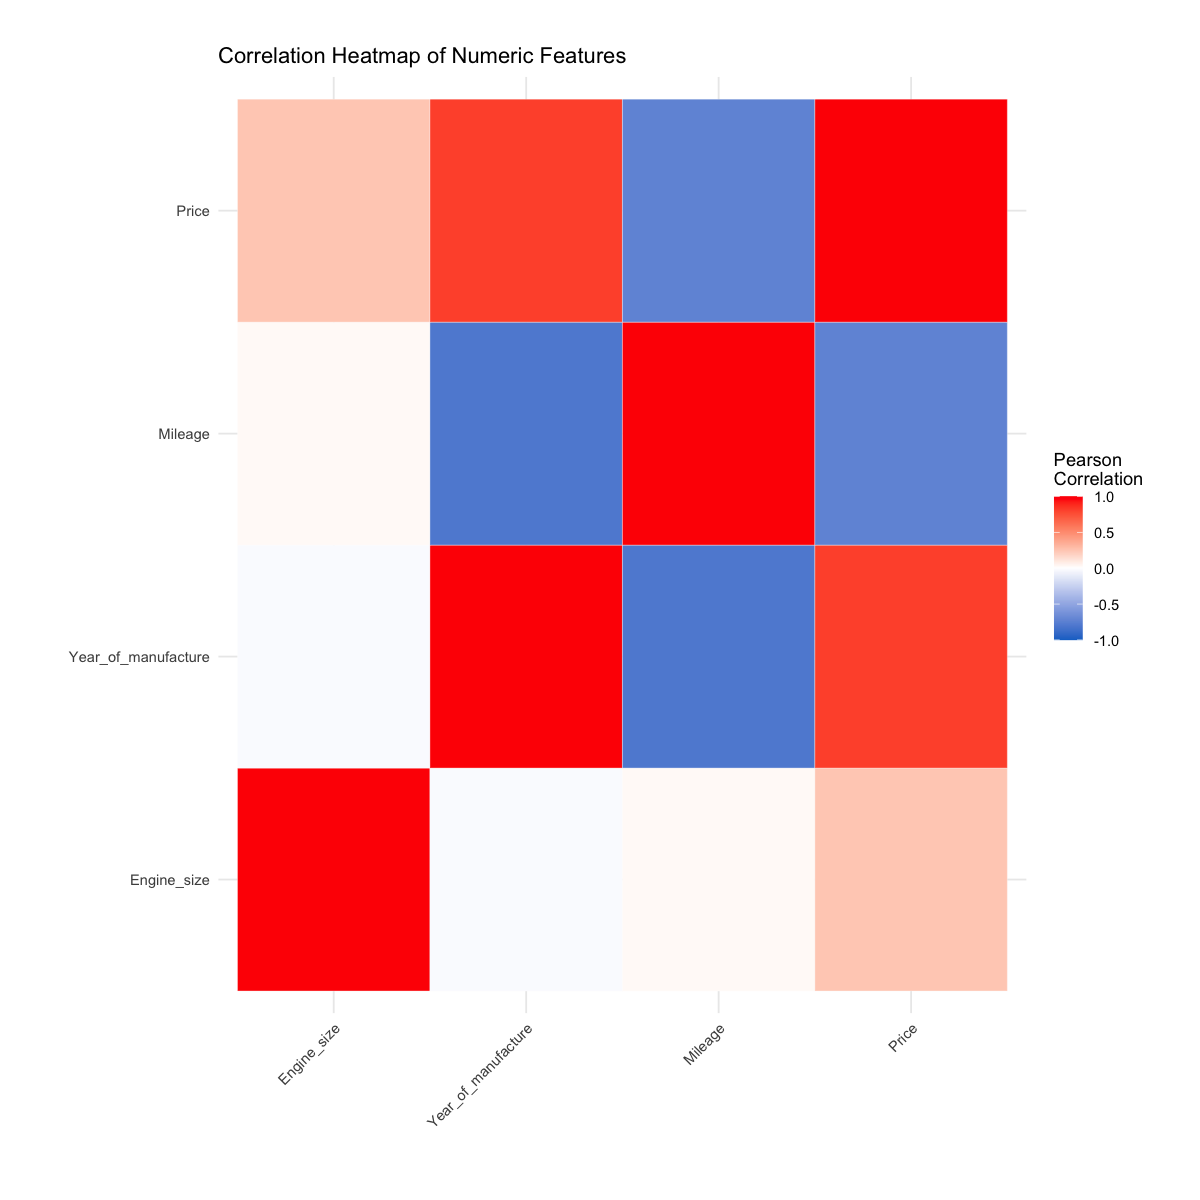

In [15]:
library(reshape2)
library(ggplot2)

# 상관관계 행렬을 긴 형태로 변환
correlation_melted <- melt(correlation_matrix)

# ggplot을 사용하여 상관관계 히트맵 생성
options(repr.plot.width = 10, repr.plot.height = 10)

ggplot(correlation_melted, aes(x = Var1, y = Var2, fill = value)) +
  geom_tile(color = "white") +
  scale_fill_gradient2(
    low = "dodgerblue3",
    mid = "white",
    high = "red",
    midpoint = 0,
    limits = c(-1, 1),
    name = "Pearson\nCorrelation"
  ) +
  theme_minimal() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    plot.margin = unit(c(1, 1, 1, 1), "cm")
  ) +
  labs(
    title = "Correlation Heatmap of Numeric Features",
    x = "",
    y = ""
  )

# Pair Plot

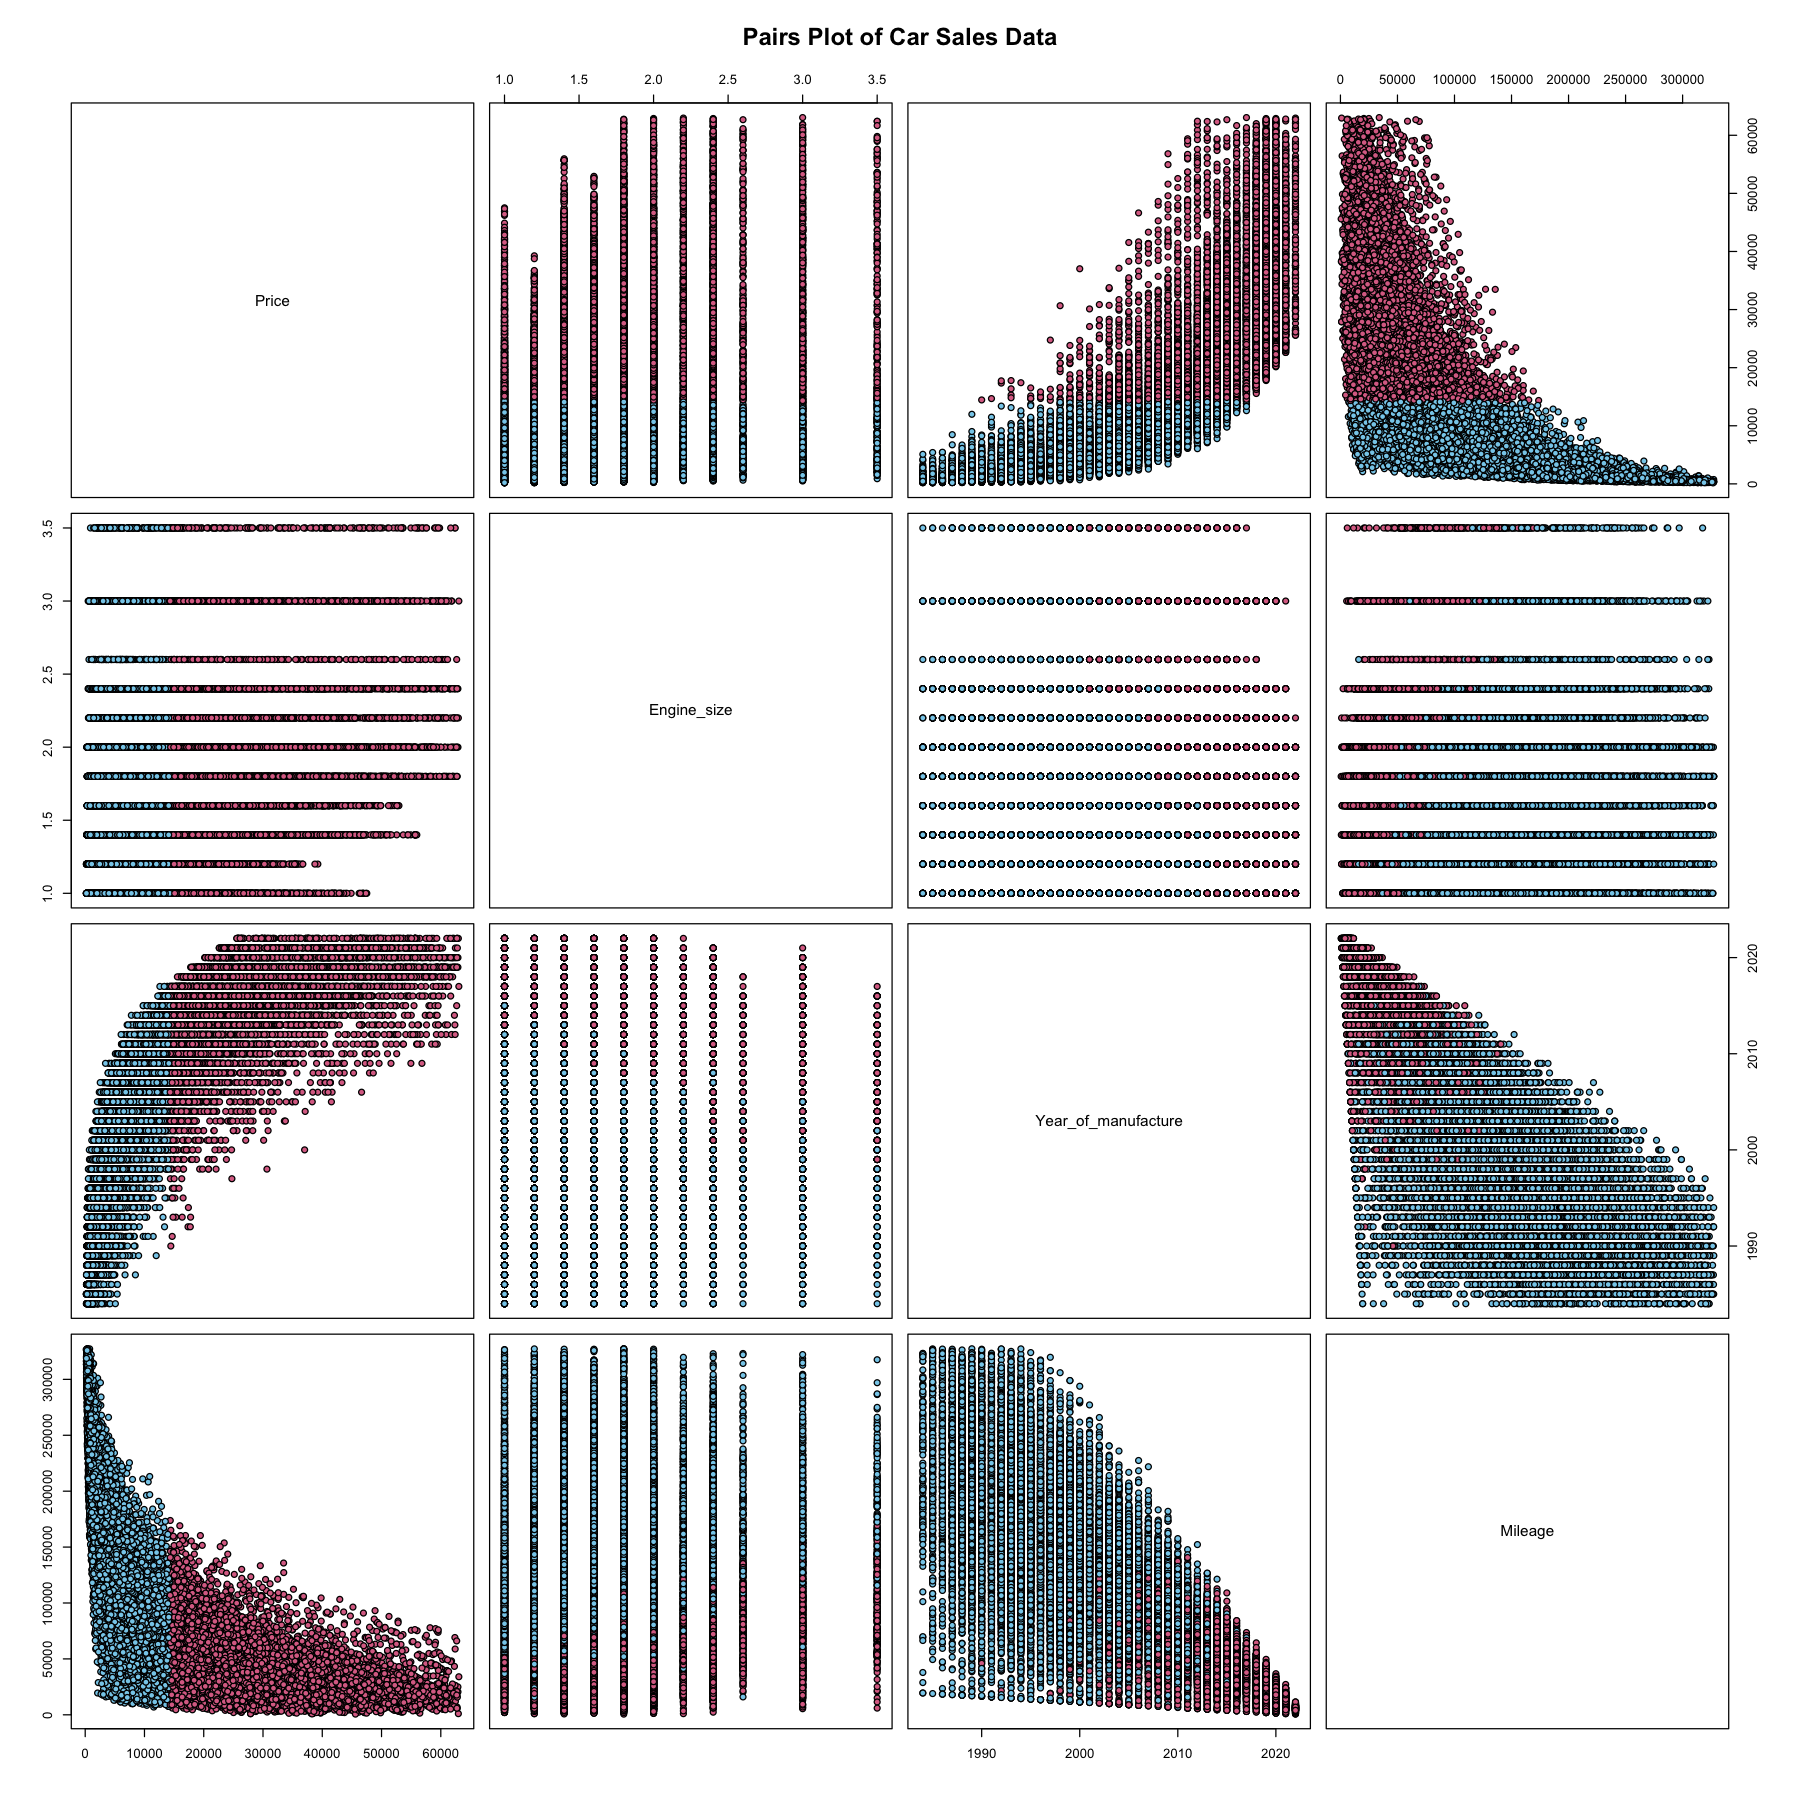

In [16]:
# 색상 벡터 생성 (가격 등급 기준)
colors <- ifelse(cars_new$Price_category == "High", "palevioletred", "skyblue")

# 쌍별 플롯
options(repr.plot.width = 15, repr.plot.height = 15)

pairs(
  cars_new[, c('Price', 'Engine_size', 'Year_of_manufacture', 'Mileage')],
  main = "Pairs Plot of Car Sales Data",
  bg = colors,
  pch = 21
)

# Box Plot

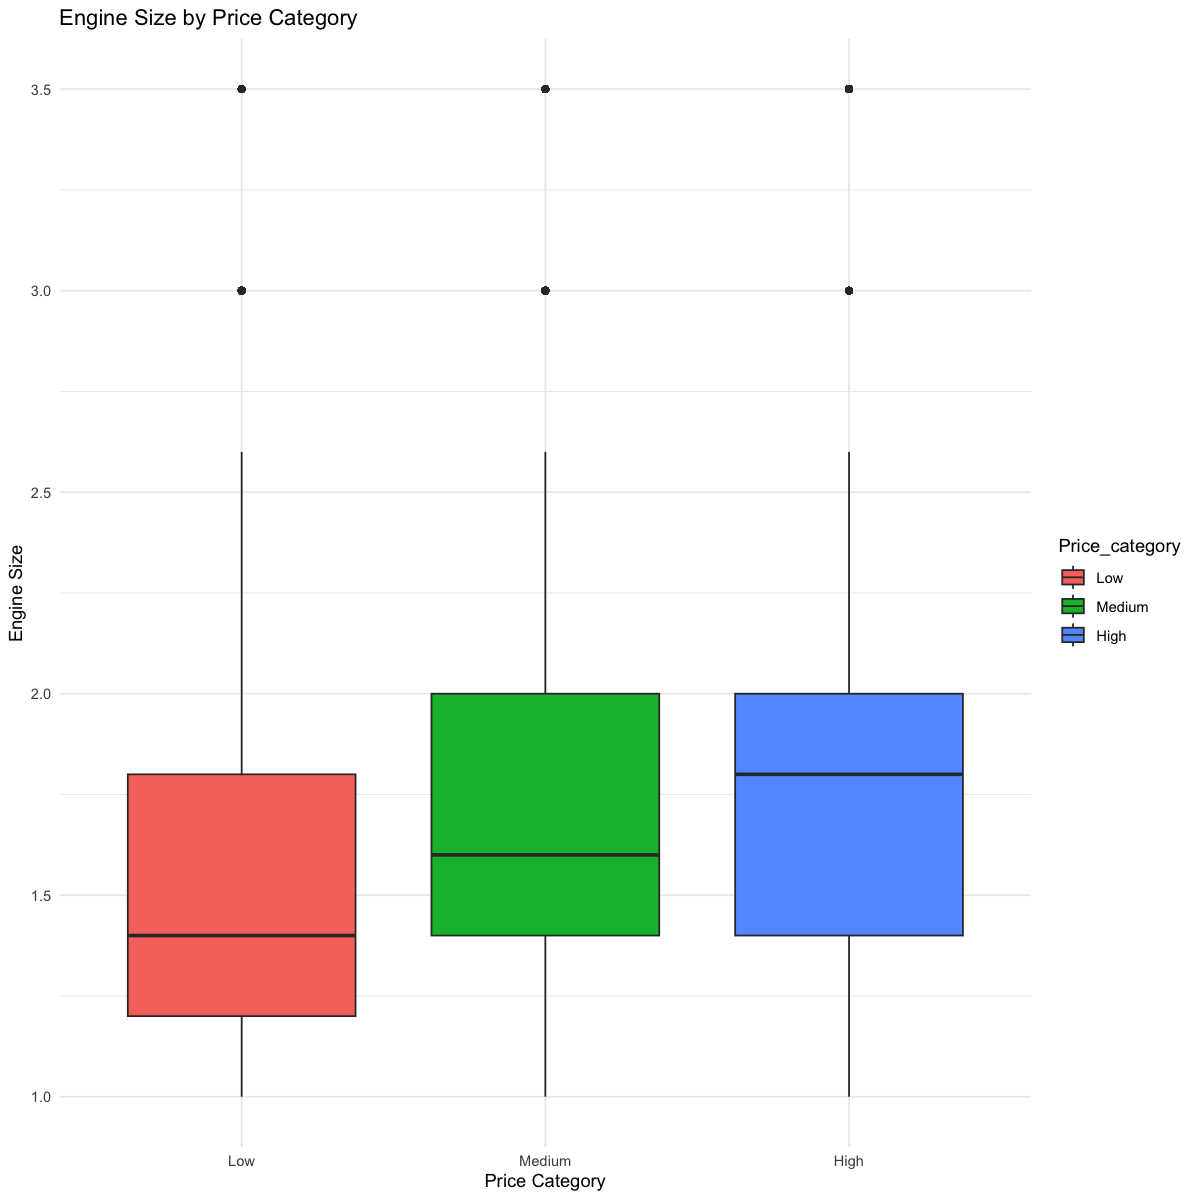

In [17]:
# 추가적인 시각화
# 가격 등급별 엔진 크기 비교

options(repr.plot.width = 10, repr.plot.height = 10)

ggplot(cars_new, aes(x = Price_category, y = Engine_size, fill = Price_category)) +
  geom_boxplot() +
  labs(
    title = "Engine Size by Price Category",
    x = "Price Category",
    y = "Engine Size"
  ) +
  theme_minimal()

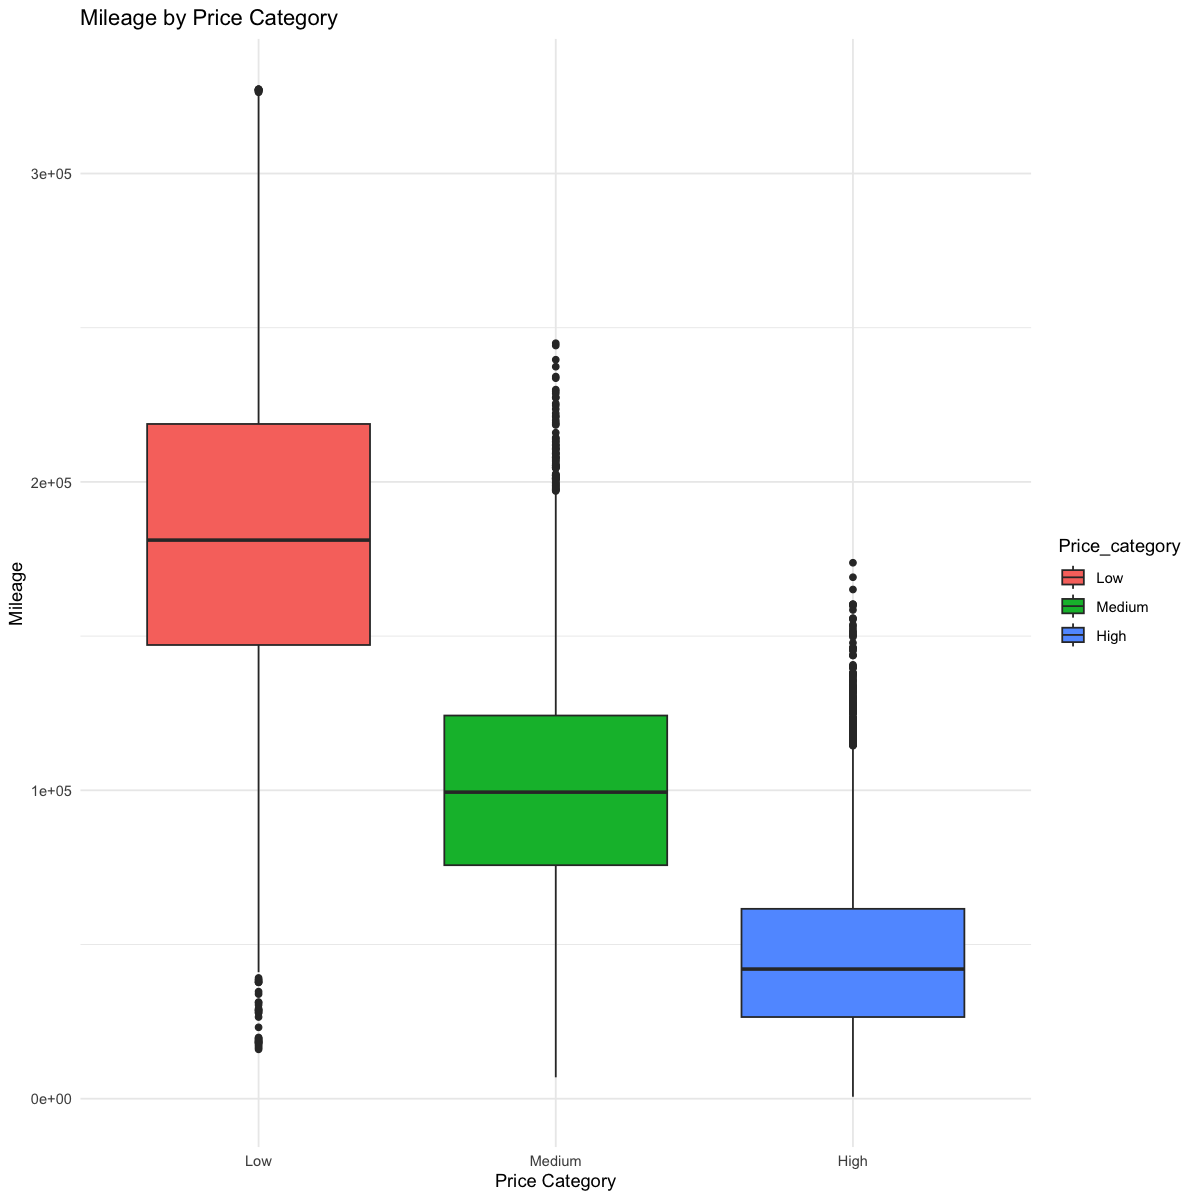

In [18]:
# Mileage 비교
ggplot(cars_new, aes(x = Price_category, y = Mileage, fill = Price_category)) +
  geom_boxplot() +
  labs(
    title = "Mileage by Price Category",
    x = "Price Category",
    y = "Mileage"
  ) +
  theme_minimal()

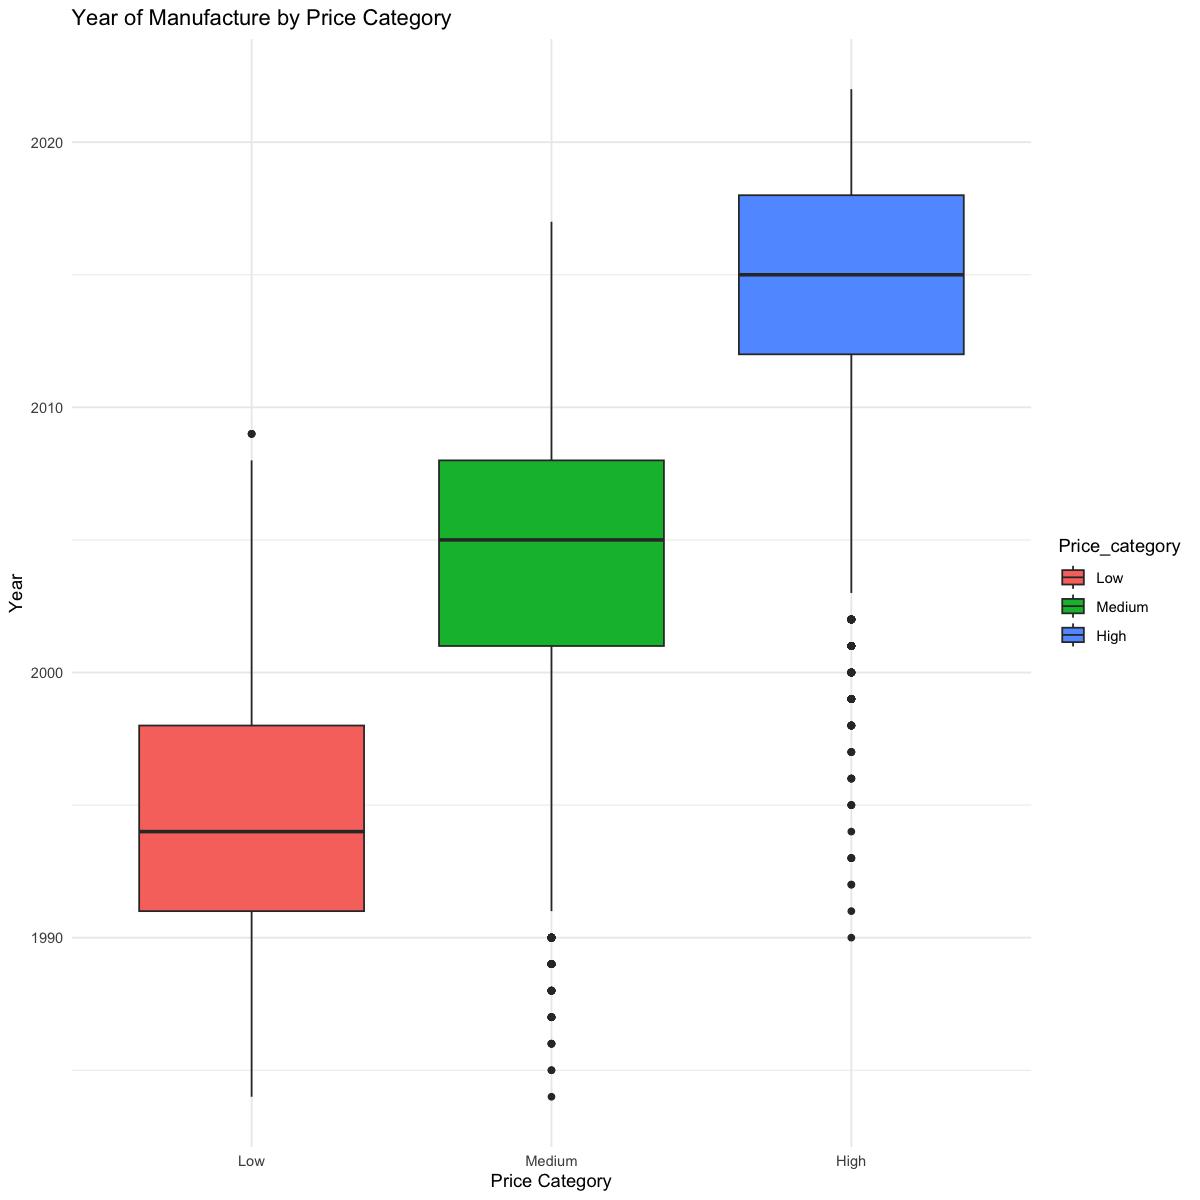

In [19]:
# 연식 비교
ggplot(cars_new, aes(x = Price_category, y = Year_of_manufacture, fill = Price_category)) +
  geom_boxplot() +
  labs(
    title = "Year of Manufacture by Price Category",
    x = "Price Category",
    y = "Year"
  ) +
  theme_minimal()

# 전체 요소에 대한 모델 학습 및 평가

## Train, Test 데이터 분할 (7:3 비율)

In [20]:
# Train, Test 데이터 분할

X <- cars_new[, !(names(cars_new) %in% c("Price_category", "Price"))]
y <- cars_new$Price_category

# factor로 변환
y <- as.factor(y)

# Create training and test datasets
set.seed(123)  # 재현성을 위한 seed 고정
splitIndex <- createDataPartition(y, p = 0.70, list = FALSE)

X_train <- X[splitIndex, ]
y_train <- y[splitIndex]

X_test <- X[-splitIndex, ]
y_test <- y[-splitIndex]

print(dim(cars_new))
print(dim(X_train))
print(dim(X_test))
print(length(y_train))
print(length(y_test))

[1] 47152     8
[1] 33008     6
[1] 14144     6
[1] 33008
[1] 14144


## SVM 모델 학습 및 평가

In [21]:
# SVM 모델
y_train <- as.factor(y_train)
model <- svm(y_train ~ ., data = X_train, probability = TRUE)
print(summary(model))


Call:
svm(formula = y_train ~ ., data = X_train, probability = TRUE)


Parameters:
   SVM-Type:  C-classification 
 SVM-Kernel:  radial 
       cost:  1 

Number of Support Vectors:  4526

 ( 1117 1147 2262 )


Number of Classes:  3 

Levels: 
 Low Medium High





In [22]:
# 예측
predictions <- predict(model, X_test)

# factor level 맞추기
predictions <- factor(predictions, levels = levels(y_test))
y_test_f <- factor(y_test, levels = levels(y_test))

# 혼동 행렬
cm <- confusionMatrix(predictions, y_test_f)
print(cm)

Confusion Matrix and Statistics

          Reference
Prediction  Low Medium High
    Low    4825     28    0
    Medium   33   4766   28
    High      0     40 4424

Overall Statistics
                                          
               Accuracy : 0.9909          
                 95% CI : (0.9892, 0.9924)
    No Information Rate : 0.3435          
    P-Value [Acc > NIR] : < 2.2e-16       
                                          
                  Kappa : 0.9863          
                                          
 Mcnemar's Test P-Value : NA              

Statistics by Class:

                     Class: Low Class: Medium Class: High
Sensitivity              0.9932        0.9859      0.9937
Specificity              0.9970        0.9934      0.9959
Pos Pred Value           0.9942        0.9874      0.9910
Neg Pred Value           0.9964        0.9927      0.9971
Prevalence               0.3435        0.3418      0.3148
Detection Rate           0.3411        0.3370      0.3128

In [23]:
# 혼동 행렬을 기반으로 정밀도, 재현율, F1 점수를 계산
metrics <- data.frame(
  class = rownames(cm$byClass),
  precision = cm$byClass[, "Precision"],
  recall = cm$byClass[, "Recall"],
  f1 = cm$byClass[, "F1"]
)

# 클래스를 기준으로 오름차순 정렬
metrics <- metrics[order(metrics$class), ]

rownames(metrics) <- NULL
metrics[is.na(metrics)] <- 0

# 결과를 출력합니다.
print(metrics, row.names = FALSE)

         class precision    recall        f1
   Class: High 0.9910394 0.9937107 0.9923733
    Class: Low 0.9942304 0.9932071 0.9937185
 Class: Medium 0.9873628 0.9859330 0.9866473


## 의사결정나무 모델 학습 및 평가

In [24]:
# 의사결정나무 모델
y_train <- as.factor(y_train)
dt_model <- rpart(y_train ~ ., data = X_train)
print(summary(dt_model))

Call:
rpart(formula = y_train ~ ., data = X_train)
  n= 33008 

          CP nsplit rel error    xerror        xstd
1 0.42416132      0 1.0000000 1.0043376 0.003973122
2 0.26500854      1 0.5758387 0.5744543 0.004063307
3 0.02219556      2 0.3108301 0.3138757 0.003391018
4 0.01744267      4 0.2664390 0.2649162 0.003177780
5 0.01698122      5 0.2489964 0.2490886 0.003100710
6 0.01190531      7 0.2150339 0.2141110 0.002913968
7 0.01000000      8 0.2031286 0.2029440 0.002849036

Variable importance
Year_of_manufacture             Mileage               Model         Engine_size 
                 52                  35                   7                   2 
       Manufacturer           Fuel_type 
                  2                   2 

Node number 1: 33008 observations,    complexity param=0.4241613
  predicted class=Low     expected loss=0.6565378  P(node) =1
    class counts: 11337 11281 10390
   probabilities: 0.343 0.342 0.315 
  left son=2 (21916 obs) right son=3 (11092 obs)
  Pri

In [25]:
# 예측
predictions_dt <- predict(dt_model, X_test, type = "class")
y_test_f <- as.factor(y_test)

cm <- confusionMatrix(predictions_dt, y_test_f)
print(cm)

Confusion Matrix and Statistics

          Reference
Prediction  Low Medium High
    Low    4320    387    0
    Medium  538   4185  652
    High      0    262 3800

Overall Statistics
                                          
               Accuracy : 0.87            
                 95% CI : (0.8643, 0.8755)
    No Information Rate : 0.3435          
    P-Value [Acc > NIR] : < 2.2e-16       
                                          
                  Kappa : 0.8046          
                                          
 Mcnemar's Test P-Value : NA              

Statistics by Class:

                     Class: Low Class: Medium Class: High
Sensitivity              0.8893        0.8657      0.8535
Specificity              0.9583        0.8722      0.9730
Pos Pred Value           0.9178        0.7786      0.9355
Neg Pred Value           0.9430        0.9260      0.9353
Prevalence               0.3435        0.3418      0.3148
Detection Rate           0.3054        0.2959      0.2687

In [26]:
# 혼동 행렬을 기반으로 정밀도, 재현율, F1 점수를 계산
metrics <- data.frame(
  class = rownames(cm$byClass),
  precision = cm$byClass[, "Precision"],
  recall = cm$byClass[, "Recall"],
  f1 = cm$byClass[, "F1"]
)

# 클래스를 기준으로 오름차순 정렬
metrics <- metrics[order(metrics$class), ]

rownames(metrics) <- NULL
metrics[is.na(metrics)] <- 0

# 결과를 출력합니다.
print(metrics, row.names = FALSE)

         class precision    recall        f1
   Class: High 0.9354998 0.8535490 0.8926474
    Class: Low 0.9177820 0.8892548 0.9032933
 Class: Medium 0.7786047 0.8657427 0.8198648


## 랜덤포레스트 모델 학습 및 평가

In [27]:
# 랜덤포레스트 모델
y_train <- as.factor(y_train)
rf_model <- randomForest(y_train ~ ., data = X_train)
print(summary(rf_model))

                Length Class  Mode     
call                3  -none- call     
type                1  -none- character
predicted       33008  factor numeric  
err.rate         2000  -none- numeric  
confusion          12  -none- numeric  
votes           99024  matrix numeric  
oob.times       33008  -none- numeric  
classes             3  -none- character
importance          6  -none- numeric  
importanceSD        0  -none- NULL     
localImportance     0  -none- NULL     
proximity           0  -none- NULL     
ntree               1  -none- numeric  
mtry                1  -none- numeric  
forest             14  -none- list     
y               33008  factor numeric  
test                0  -none- NULL     
inbag               0  -none- NULL     
terms               3  terms  call     


In [28]:
# 예측
predictions_rf <- predict(rf_model, X_test)

# factor level 맞추기
predictions_rf <- factor(predictions_rf, levels = levels(y_test))
y_test_f <- factor(y_test, levels = levels(y_test))

# 혼동 행렬
cm <- confusionMatrix(predictions_rf, y_test_f)
print(cm)

Confusion Matrix and Statistics

          Reference
Prediction  Low Medium High
    Low    4776     76    0
    Medium   82   4712   94
    High      0     46 4358

Overall Statistics
                                          
               Accuracy : 0.9789          
                 95% CI : (0.9764, 0.9812)
    No Information Rate : 0.3435          
    P-Value [Acc > NIR] : < 2.2e-16       
                                          
                  Kappa : 0.9684          
                                          
 Mcnemar's Test P-Value : NA              

Statistics by Class:

                     Class: Low Class: Medium Class: High
Sensitivity              0.9831        0.9748      0.9789
Specificity              0.9918        0.9811      0.9953
Pos Pred Value           0.9843        0.9640      0.9896
Neg Pred Value           0.9912        0.9868      0.9903
Prevalence               0.3435        0.3418      0.3148
Detection Rate           0.3377        0.3331      0.3081

In [29]:
# 혼동 행렬을 기반으로 정밀도, 재현율, F1 점수를 계산
metrics <- data.frame(
  class = rownames(cm$byClass),
  precision = cm$byClass[, "Precision"],
  recall = cm$byClass[, "Recall"],
  f1 = cm$byClass[, "F1"]
)

# 클래스를 기준으로 오름차순 정렬
metrics <- metrics[order(metrics$class), ]

rownames(metrics) <- NULL
metrics[is.na(metrics)] <- 0

# 결과를 출력합니다.
print(metrics, row.names = FALSE)

         class precision    recall        f1
   Class: High 0.9895550 0.9788859 0.9841915
    Class: Low 0.9843364 0.9831206 0.9837281
 Class: Medium 0.9639935 0.9747621 0.9693479


## 머신러닝 모형과 로지스틱 회귀모형 기반의 평점표

In [30]:
# SVM
svm_pred <- predict(model, X_test, type = "class")
svm_acc <- sum(svm_pred == y_test) / length(y_test)

# Decision Tree
dt_pred <- predict(dt_model, X_test, type = "class")
dt_acc <- sum(dt_pred == y_test) / length(y_test)

# Random Forest
rf_pred <- predict(rf_model, X_test, type = "class")
rf_acc <- sum(rf_pred == y_test) / length(y_test)

# 결과 출력
cat("SVM Accuracy: ", svm_acc, "\n")
cat("Decision Tree Accuracy: ", dt_acc, "\n")
cat("Random Forest Accuracy: ", rf_acc, "\n")

SVM Accuracy:  0.9908795 
Decision Tree Accuracy:  0.8699802 
Random Forest Accuracy:  0.978931 


## 모형들 간의 AUROC 비교
- 본 프로젝트에서 사용한 모델이 이진 분류 모델이 아닌 다중 분류 모델이므로 AUROC도 다중 클래스 모델에 대한 분석을 진행함

In [31]:
# 필요한 패키지 로드
library(pROC)

class_levels <- levels(as.factor(y_test))

compute_auroc <- function(prob_matrix, y_true, model_name) {
  cat(paste0("\n[ ", model_name, " AUROC ]\n"))
  
  for (class in class_levels) {
    if (sum(y_true == class) > 0 && class %in% colnames(prob_matrix)) {
      response <- as.integer(y_true == class)
      class_prob <- prob_matrix[, class]
      
      # 메시지 출력 없이 ROC 계산
      roc_obj <- roc(response, class_prob, quiet = TRUE)
      
      cat(model_name, "AUROC for class", class, ":", round(as.numeric(auc(roc_obj)), 4), "\n")
    }
  }
}

# 예측 확률
svm_pred <- predict(model, X_test, probability = TRUE)
svm_prob <- attr(svm_pred, "probabilities")

dt_prob <- predict(dt_model, X_test, type = "prob")
rf_prob <- predict(rf_model, X_test, type = "prob")

# 출력
compute_auroc(svm_prob, y_test, "SVM")
compute_auroc(dt_prob, y_test, "Decision Tree")
compute_auroc(rf_prob, y_test, "Random Forest")

Type 'citation("pROC")' for a citation.


다음의 패키지를 부착합니다: ‘pROC’


The following objects are masked from ‘package:stats’:

    cov, smooth, var





[ SVM AUROC ]
SVM AUROC for class Low : 0.9999 
SVM AUROC for class Medium : 0.9995 
SVM AUROC for class High : 0.9996 

[ Decision Tree AUROC ]
Decision Tree AUROC for class Low : 0.9637 
Decision Tree AUROC for class Medium : 0.8885 
Decision Tree AUROC for class High : 0.9602 

[ Random Forest AUROC ]
Random Forest AUROC for class Low : 0.9996 
Random Forest AUROC for class Medium : 0.9984 
Random Forest AUROC for class High : 0.9996 


In [32]:
# Random Forest Feature Importance 추출
rf_importance <- importance(rf_model)

# 데이터프레임으로 변환
importance_df <- data.frame(
  Feature = rownames(rf_importance),
  MeanDecreaseGini = rf_importance[, "MeanDecreaseGini"]
)

# 중요도 순으로 정렬
importance_df <- importance_df[order(importance_df$MeanDecreaseGini, decreasing = TRUE), ]

# 출력
print(importance_df)

                                Feature MeanDecreaseGini
Year_of_manufacture Year_of_manufacture        9781.4320
Mileage                         Mileage        7644.6906
Engine_size                 Engine_size        1275.8507
Model                             Model        1170.9335
Fuel_type                     Fuel_type         398.3039
Manufacturer               Manufacturer         329.0664


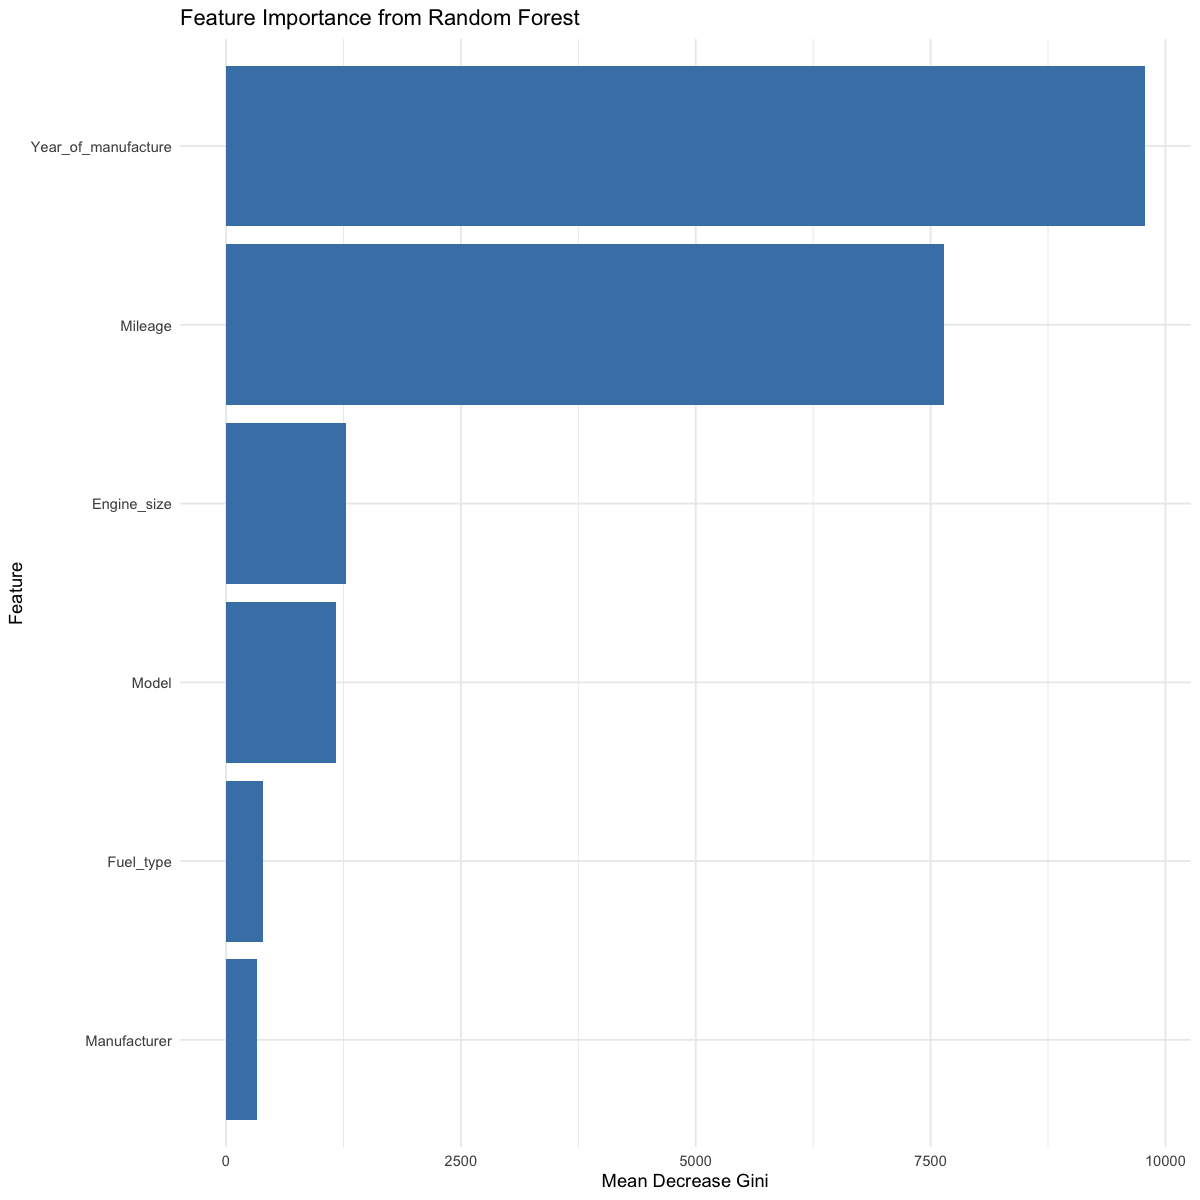

In [33]:
library(ggplot2)

ggplot(importance_df, aes(x = reorder(Feature, MeanDecreaseGini), y = MeanDecreaseGini)) +
  geom_bar(stat = "identity", fill = "steelblue") +
  coord_flip() +
  labs(
    title = "Feature Importance from Random Forest",
    x = "Feature",
    y = "Mean Decrease Gini"
  ) +
  theme_minimal()

## 3. 프로젝트 결과

### 1) 데이터 분석 결과

#### (1) 이상치 확인 및 제거

본 프로젝트에서는 데이터의 품질을 높이기 위해 이상치(outlier)를 제거하였다.  
이를 위해 모든 수치형 변수에 대해 Z-score를 계산하고, 각 변수에서 |Z| < 3 조건을 만족하는 데이터만 유지하였다.

이 과정을 통해 평균에서 크게 벗어난 데이터를 제거하여 모델 학습 시 데이터의 왜곡을 줄이고 보다 안정적인 학습이 가능하도록 하였다.

실험 결과 전체 50,000개의 데이터 중 2,848개의 이상치가 제거되었으며, 이는 전체 데이터의 약 5.7%에 해당한다.


#### (2) Correlation Matrix & Heatmap

데이터 변수 간 관계를 파악하기 위해 수치형 변수에 대한 상관관계(Correlation) 분석을 수행하였다.

각 변수 간 Pearson correlation coefficient를 계산하여 Correlation Matrix를 생성하고 이를 Heatmap으로 시각화하였다.

분석 결과 다음과 같은 주요 관계가 확인되었다.

- Year_of_manufacture ↔ Price : 강한 양의 상관관계
- Mileage ↔ Price : 강한 음의 상관관계
- Year_of_manufacture ↔ Mileage : 강한 음의 상관관계

이는 다음과 같은 해석이 가능하다.

- 연식이 최신일수록 차량 가격이 높다
- 주행거리가 많을수록 차량 가격이 낮다

즉, 차량의 연식과 주행거리는 가격을 결정하는 주요 요인임을 확인할 수 있다.


#### (3) Pair Plot

Pair Plot은 여러 변수 간 관계를 한눈에 확인할 수 있는 시각화 기법이다.

본 프로젝트에서는 다음 변수들을 대상으로 Pair Plot을 생성하였다.

- Price
- Engine_size
- Year_of_manufacture
- Mileage

Pair Plot 분석을 통해 다음과 같은 패턴을 확인할 수 있었다.

- 연식이 최신일수록 가격이 높아지는 경향
- 주행거리가 증가할수록 가격이 감소하는 경향
- 엔진 크기가 클수록 가격이 다소 높아지는 경향

또한 Price_category를 기준으로 색상을 구분하여 가격 등급에 따른 데이터 분포 차이도 확인할 수 있었다.


#### (4) Box Plot

Box Plot을 이용하여 가격 등급별 변수 분포를 비교하였다.

Box Plot 분석 결과 다음과 같은 특징이 나타났다.

Engine Size
- High 가격 등급 차량이 평균적으로 더 큰 엔진 크기를 보였다.

Mileage
- Low 가격 차량은 높은 주행거리를 가지는 경향이 있다.
- High 가격 차량은 비교적 낮은 주행거리를 가진다.

Year of Manufacture
- High 가격 차량은 최신 연식 차량이 많다.
- Low 가격 차량은 비교적 오래된 차량이 많다.

이러한 결과는 차량 가격이 연식, 주행거리, 엔진 크기와 밀접한 관련이 있음을 보여준다.


### 2) 모든 요소에 대한 모델 학습 및 평가

본 프로젝트에서는 다음 머신러닝 모델을 사용하여 차량 가격 등급을 예측하였다.

- Support Vector Machine (SVM)
- Decision Tree
- Random Forest


#### (1) 모델 정확도 비교

각 모델의 정확도는 다음과 같다.

| 모델 | Accuracy |
|---|---|
| SVM | 0.9909 |
| Decision Tree | 0.8699 |
| Random Forest | 0.9789 |

분석 결과

- SVM 모델이 가장 높은 정확도(99.09%)를 보였다.
- Random Forest 또한 매우 높은 성능(97.89%)을 보였다.
- Decision Tree는 상대적으로 낮은 성능을 보였다.

이는 Decision Tree가 단일 트리 구조이기 때문에 복잡한 데이터 패턴을 충분히 반영하지 못할 가능성이 있기 때문이다.

반면 Random Forest는 여러 트리를 결합한 앙상블 모델이며, SVM은 복잡한 경계를 학습하는 데 강점이 있는 모델이기 때문에 더 높은 성능을 보인 것으로 해석된다.


#### (2) AUROC 분석

다중 클래스 분류 문제이기 때문에 각 클래스에 대해 AUROC를 계산하였다.

SVM

| Class | AUROC |
|---|---|
Low | 0.9999 |
Medium | 0.9995 |
High | 0.9996 |

Decision Tree

| Class | AUROC |
|---|---|
Low | 0.9637 |
Medium | 0.8885 |
High | 0.9602 |

Random Forest

| Class | AUROC |
|---|---|
Low | 0.9996 |
Medium | 0.9984 |
High | 0.9996 |

분석 결과

- SVM과 Random Forest가 거의 완벽한 분류 성능을 보였다.
- Decision Tree는 상대적으로 낮은 AUROC 값을 보였다.

이는 Random Forest와 SVM이 데이터의 복잡한 패턴을 더 잘 학습할 수 있기 때문으로 해석된다.


### 3) Feature Importance 분석

Random Forest 모델을 이용하여 변수 중요도를 분석하였다.

Feature Importance 결과는 다음과 같다.

| Feature | Importance |
|---|---|
Year_of_manufacture | 9781.43 |
Mileage | 7644.69 |
Engine_size | 1275.85 |
Model | 1170.93 |
Fuel_type | 398.30 |
Manufacturer | 329.06 |

분석 결과

- Year_of_manufacture가 차량 가격을 예측하는 가장 중요한 변수로 나타났다.
- Mileage 또한 매우 중요한 변수로 확인되었다.
- Engine_size는 비교적 중간 정도의 중요도를 보였다.

즉 차량 가격은 주로 연식과 주행거리의 영향을 가장 크게 받는 것으로 나타났다.

## 4. 토론 및 결론

본 프로젝트에서는 차량 판매 데이터(Car Sales Dataset)를 활용하여 차량의 주요 특성이 가격 등급에 미치는 영향을 분석하고, 여러 머신러닝 모델을 이용하여 차량 가격 등급을 예측하는 실험을 수행하였다.

먼저 데이터 전처리 과정에서 Z-score 기반 이상치 제거를 수행하여 데이터 품질을 개선하였다. 이후 상관관계 분석과 다양한 시각화를 통해 변수 간 관계를 분석한 결과, 차량 가격은 특히 **연식(Year_of_manufacture)**과 **주행거리(Mileage)**와 강한 관계를 가지는 것으로 나타났다. 일반적으로 연식이 최신일수록 가격이 높고, 주행거리가 많을수록 가격이 낮아지는 경향이 확인되었다. 또한 **엔진 크기(Engine_size)** 역시 가격과 일정한 관계를 가지는 변수로 확인되었다.

이후 Support Vector Machine(SVM), Decision Tree, Random Forest 모델을 사용하여 차량 가격 등급을 예측하였다. 실험 결과 SVM과 Random Forest 모델이 높은 성능을 보였으며, 특히 SVM 모델이 가장 높은 정확도를 나타냈다. 반면 Decision Tree 모델은 상대적으로 낮은 성능을 보였는데, 이는 단일 트리 구조의 한계로 인해 데이터의 복잡한 패턴을 충분히 학습하지 못했기 때문으로 해석할 수 있다.

또한 Random Forest 모델의 Feature Importance 분석을 통해 차량 가격 등급 예측에 중요한 변수들을 확인하였다. 분석 결과 **Year_of_manufacture**와 **Mileage**가 가장 중요한 변수로 나타났으며, 이는 차량 가격이 차량의 사용 이력과 연식에 크게 영향을 받는다는 점을 보여준다. Engine_size 또한 가격과 관련된 중요한 변수로 나타났다.

다만 본 연구에는 몇 가지 한계가 존재한다. 첫째, 데이터에 차량의 브랜드와 모델 정보가 포함되어 있어 특정 차량 모델이 가격 등급을 강하게 설명할 가능성이 있다. 둘째, 실제 차량 가격은 옵션, 차량 상태, 지역 등의 다양한 요소에 의해 결정되지만 이러한 변수들은 본 데이터셋에 포함되지 않았다. 향후 연구에서는 더 다양한 차량 특성과 시장 데이터를 활용하여 보다 현실적인 가격 예측 모델을 구축할 필요가 있다.

결론적으로 본 프로젝트를 통해 차량 가격 등급은 **연식, 주행거리, 엔진 크기와 같은 차량의 기본 특성과 밀접한 관계가 있으며**, 머신러닝 모델을 활용하면 이러한 특성을 기반으로 차량 가격 등급을 효과적으로 예측할 수 있음을 확인하였다.